# Group velocity vs phase velocity -- watch the envelope outrun the wave
### SymPy derivation + a wave packet you can see move

A wave has two speeds. The **phase velocity** $v_p=\omega/k$ is how fast a single
crest moves. The **group velocity** $v_g=d\omega/dk$ is how fast the *envelope*
(the bump that carries the energy and the information) moves. When the medium is
**dispersive** they differ -- and you can watch the carrier slide *through* a
slower-or-faster envelope. We use $\omega=\alpha k^2$, which gives $v_g=2v_p$ --
the same factor as a wave in a conductor (Griffiths 9.4.1). Civilian optics.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, matplotlib.pyplot as plt
import sympy as sp
sp.init_printing()
print("loaded")

loaded


## 1. The two velocities (SymPy)

For the dispersion relation $\omega(k)=\alpha k^2$:
$v_p=\omega/k=\alpha k$ and $v_g=d\omega/dk=2\alpha k=2v_p$.

In [2]:
k, alpha = sp.symbols("k alpha", positive=True)
omega = alpha*k**2
vp = sp.simplify(omega/k)
vg = sp.simplify(sp.diff(omega, k))
print("dispersion  omega(k) =", omega)
print("phase velocity v_p = omega/k   =", vp)
print("group velocity v_g = domega/dk =", vg, "  ->  v_g = 2 v_p")

dispersion  omega(k) = alpha*k**2
phase velocity v_p = omega/k   = alpha*k
group velocity v_g = domega/dk = 2*alpha*k   ->  v_g = 2 v_p


## 2. Two-wave beat -- the envelope moves at $v_g$, the carrier at $v_p$

Add two waves at $k_0\pm\Delta k$. They beat into a fast **carrier** under a slow
**envelope**. Snapshot at $t=0$ and a later $t$: the carrier shifts by $v_p t$,
the envelope by $v_g t = 2 v_p t$ -- so the envelope pulls ahead of the crests.

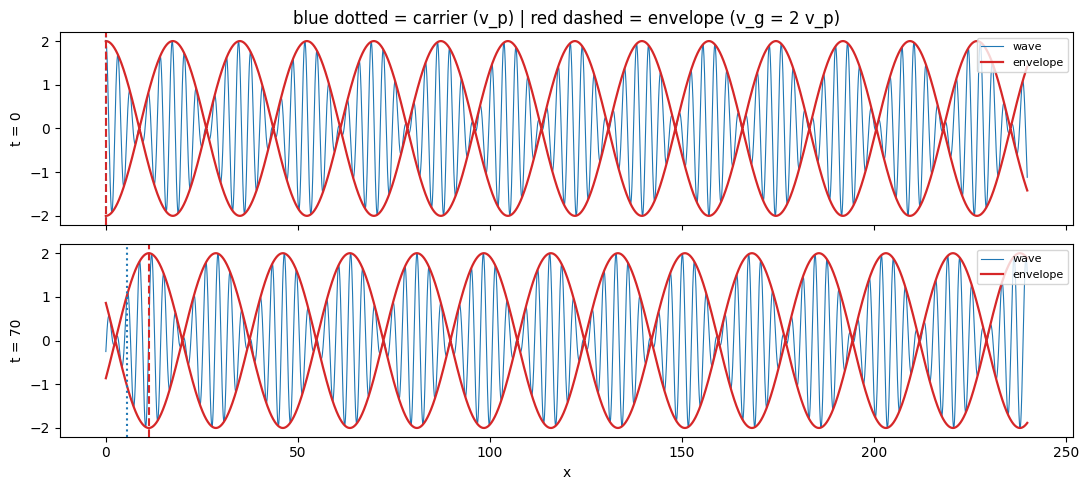

after t=70: carrier moved 5.6, envelope moved 11.2 (= 2x)


In [3]:
a = 0.04
k0, dk = 2.0, 0.18
k1, k2 = k0 - dk, k0 + dk
w1, w2 = a*k1**2, a*k2**2
vp_n, vg_n = a*k0, 2*a*k0
x = np.linspace(0, 240, 6000)

def psi(t):
    return np.cos(k1*x - w1*t) + np.cos(k2*x - w2*t)
def envelope(t):
    return 2*np.abs(np.cos(dk*x - (w2-w1)/2*t))

T = 70.0
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for a_, t, tag in [(ax[0], 0.0, "t = 0"), (ax[1], T, f"t = {T:.0f}")]:
    a_.plot(x, psi(t), color="#1f77b4", lw=0.8, label="wave")
    a_.plot(x, envelope(t), color="#d62728", lw=1.6, label="envelope")
    a_.plot(x, -envelope(t), color="#d62728", lw=1.6)
    a_.axvline(vp_n*t, color="#1f77b4", ls=":", lw=1.5)   # a carrier crest
    a_.axvline(vg_n*t, color="#d62728", ls="--", lw=1.5)  # the envelope peak
    a_.set_ylabel(tag); a_.legend(loc="upper right", fontsize=8)
ax[1].set_xlabel("x")
ax[0].set_title("blue dotted = carrier (v_p) | red dashed = envelope (v_g = 2 v_p)")
plt.tight_layout(); plt.show()
print(f"after t={T:.0f}: carrier moved {vp_n*T:.1f}, envelope moved {vg_n*T:.1f} (= 2x)")

## 3. A Gaussian wave packet -- propagate it and measure $v_g$

Build a Gaussian packet centered at $k_0$, propagate with $\psi(x,t)=\mathcal F^{-1}
[\hat\psi_0\,e^{-i\omega(k)t}]$, and track its peak. The peak moves at $v_g$ (not
$v_p$), and because $\omega$ is curved the packet also **spreads** (dispersion --
the same effect as the receiver's $H(f)=e^{i\pi D f^2}$).

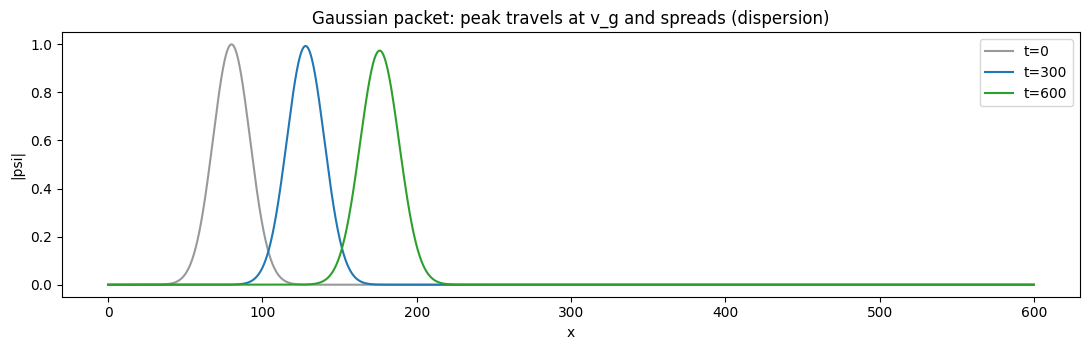

measured packet speed = 0.160   v_g = 2*alpha*k0 = 0.160   v_p = 0.080


In [4]:
N = 4096; L = 600.0
xx = np.linspace(0, L, N, endpoint=False); dxg = xx[1]-xx[0]
kk = 2*np.pi*np.fft.fftfreq(N, d=dxg)
psi0 = np.exp(-(xx-80)**2/(2*12**2)) * np.exp(1j*k0*xx)   # Gaussian packet, carrier k0
P0 = np.fft.fft(psi0)
def prop(t):
    return np.fft.ifft(P0 * np.exp(-1j*(a*kk**2)*t))
plt.figure(figsize=(11, 3.6))
peaks = []
for t, c in [(0, "#999999"), (300, "#1f77b4"), (600, "#2ca02c")]:
    A = np.abs(prop(t)); peaks.append((t, xx[np.argmax(A)]))
    plt.plot(xx, A, color=c, label=f"t={t}")
plt.xlabel("x"); plt.ylabel("|psi|"); plt.legend()
plt.title("Gaussian packet: peak travels at v_g and spreads (dispersion)")
plt.tight_layout(); plt.show()
if peaks[-1][0] > peaks[0][0]:
    v_meas = (peaks[-1][1]-peaks[0][1])/(peaks[-1][0]-peaks[0][0])
    print(f"measured packet speed = {v_meas:.3f}   v_g = 2*alpha*k0 = {2*a*k0:.3f}   v_p = {a*k0:.3f}")

## Takeaway

- **Phase velocity** $v_p=\omega/k$ moves the crests; **group velocity**
  $v_g=d\omega/dk$ moves the envelope (energy + information).
- In a dispersive medium they differ. For $\omega=\alpha k^2$, $v_g=2v_p$ -- the
  same 2:1 you found for a wave in a conductor.
- A real pulse is a packet: it travels at $v_g$ and **spreads** because $\omega(k)$
  is curved -- that curvature ($\beta_2$, group-velocity dispersion) is exactly
  what the carrier-less receiver's $H(f)=e^{i\pi D f^2}$ applies and Gerchberg-Saxton
  inverts. Civilian optics / education.